Epoch 1/100


E:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4975 - loss: 0.9834 - val_accuracy: 0.7080 - val_loss: 0.6274 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7740 - loss: 0.5668 - val_accuracy: 0.8569 - val_loss: 0.4358 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8352 - loss: 0.4299 - val_accuracy: 0.8645 - val_loss: 0.3579 - learning_rate: 0.0010
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3759 - val_accuracy: 0.8950 - val_loss: 0.3019 - learning_rate: 0.0010
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.3345 - val_accuracy: 0.9103 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8984 - loss: 0.3111 - val_accuracy: 0.9027 - val_loss: 0.2504 - learning_rate: 0.0010
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8985 - loss: 0.2702 - val_accuracy: 0.914

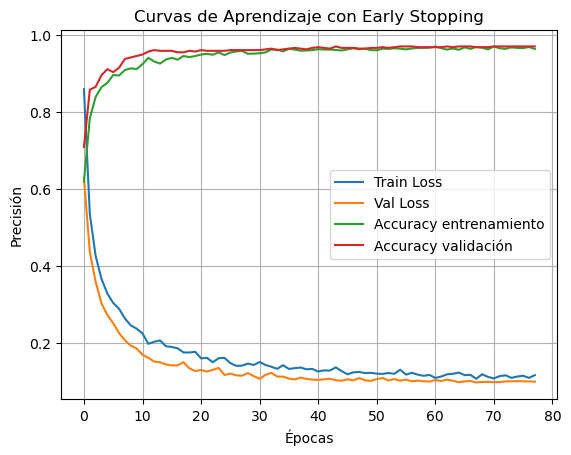

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
# Importar los callbacks necesarios
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Preparar datos
df = pd.read_csv('datasetAIQ.csv', sep=';')
X = df.drop('estimates', axis=1)
y = df['estimates']

# Escalar (Vital para que la red converja)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_encoded = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# 2. Definir el modelo
model = Sequential([
    Dense(64, input_shape=(4,), activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# 3. Compilar
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# --- OPTIMIZACIONES (CALLBACKS) ---
# EarlyStopping: Detiene el entrenamiento si no mejora tras 'patience' épocas
early_stopping = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=1)

# ReduceLROnPlateau: Reduce la velocidad de aprendizaje si se estanca
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6,verbose=1)

# 4. Entrenar (Añadimos el parámetro callbacks)
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr] 
)

# 5. Evaluar
print("Evaluando modelo optimizado...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Precisión en Test: {accuracy*100:.2f}%")

# (Opcional) Gráfico para ver cómo actuó el Early Stopping
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de Aprendizaje con Early Stopping')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.show

plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid()
plt.show()

In [49]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
# --- Plotting for Thesis (The 3 requested graphs) ---
epochs_range = range(1, len(history.history['accuracy']) + 1)
    
fig_thesis, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig_thesis.suptitle('Dinámica de Aprendizaje', fontsize=16, weight='bold')

# Accuracy
ax1.plot(epochs_range, history.history['accuracy'], 'b-', label='Entrenamiento')
ax1.plot(epochs_range, history.history['val_accuracy'], 'r--', label='Validación')
ax1.set_title('Evolución de la Precisión')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True, alpha=0.3)

    # Loss
ax2.plot(epochs_range, history.history['loss'], 'b-', label='Entrenamiento')
ax2.plot(epochs_range, history.history['val_loss'], 'r--', label='Validación')
ax2.set_title('Minimización de Pérdida (Loss)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

    # Generalization Gap
diff = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])
ax3.fill_between(epochs_range, diff, color='purple', alpha=0.2, label='Brecha (Overfitting)')
ax3.plot(epochs_range, diff, color='purple')
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Brecha de Generalización')
ax3.set_xlabel('Épocas')
ax3.set_ylabel('Diferencia Acc (Train - Val)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
fig_thesis.savefig('graficos_tesis.png')
plt.close() # Close to prevent double display if handled automatically

    # --- Plotting for Article (Recommendation: Confusion Matrix) ---
    # Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_mat = confusion_matrix(y_true, y_pred_classes)
    
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.savefig('grafico_articulo_confusion.png')
plt.close()

    # --- Plotting for Article (Alternative: Compact Learning Curve) ---
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history.history['loss'], 'k--', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], 'k-', label='Validation Loss')
plt.twinx()
plt.plot(epochs_range, history.history['accuracy'], 'g--', label='Training Acc')
plt.plot(epochs_range, history.history['val_accuracy'], 'g-', label='Validation Acc')
plt.title('Curva de Aprendizaje Compacta')
plt.xlabel('Epochs')
plt.legend(loc='upper left')
plt.savefig('grafico_articulo_curva.png')
plt.close()

print("Training and plotting complete.")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training and plotting complete.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


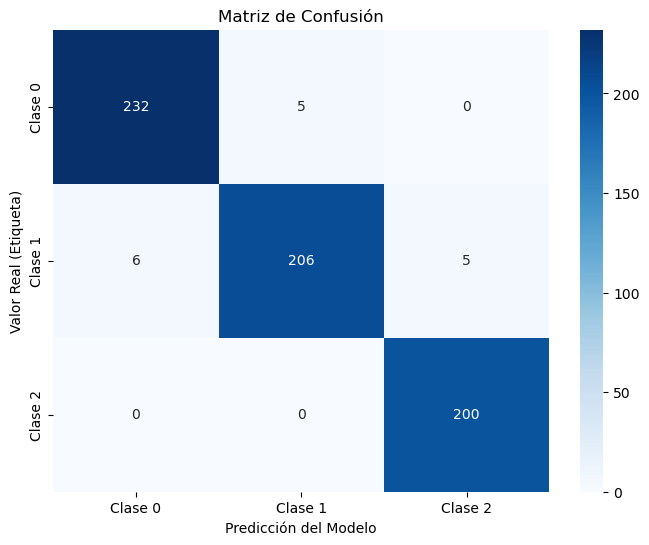

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtener las predicciones de la red
# La red devuelve probabilidades (ej: [0.1, 0.8, 0.1]), necesitamos la clase ganadora
y_pred_prob = model.predict(X_test) 
y_pred = np.argmax(y_pred_prob, axis=1) # Convierte probabilidades a enteros (0, 1, 2)

# 2. Convertir las etiquetas reales (y_test) de One-Hot a enteros
# Tu y_test actual es tipo [[0,1,0], ...], necesitamos convertirlo a [1, ...]
y_true = np.argmax(y_test, axis=1)

# 3. Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 4. Graficar con Seaborn (Mapa de calor)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,         # Pone los números dentro de los cuadros
            fmt='d',            # Formato entero (sin decimales)
            cmap='Blues',       # Mapa de color azul (puedes cambiar a 'OrRd', 'Greens', etc.)
            xticklabels=['Clase 0', 'Clase 1', 'Clase 2'], # Nombres de tus clases
            yticklabels=['Clase 0', 'Clase 1', 'Clase 2'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión')
plt.show()

In [55]:
plt.figure(figsize=(10, 6))

# Eje izquierdo (loss)
ax1 = plt.gca()
l1, = ax1.plot(epochs_range, history.history['loss'], 'k--', label='Training Loss')
l2, = ax1.plot(epochs_range, history.history['val_loss'], 'k-', label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

# Eje derecho (accuracy)
ax2 = ax1.twinx()
l3, = ax2.plot(epochs_range, history.history['accuracy'], 'g--', label='Training Acc')
l4, = ax2.plot(epochs_range, history.history['val_accuracy'], 'g-', label='Validation Acc')
ax2.set_ylabel('Accuracy')

# Combinar líneas para una sola leyenda
lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc='upper left')

plt.title('Curva de Aprendizaje Compacta')
plt.savefig('grafico_articulo_curva.png')
plt.close()

print("Training and plotting complete.")

Training and plotting complete.


In [7]:
import joblib
model.save("modelo_red.h5")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']